### Production CNN Model ensemble on the test (holdout data) scale images from AFSC, ADFG, DFO, and NSRAA

Each model, (1) EfficientNetV2L, (2) NASNetLarge, and (3) ConvNeXtLrg were trained independently on the training and validation preprocessed SAM datasets, which were from the same agencies. The SAM image data were randomly split into the Training (n=10916), Validation (n=2343), and Testing (n=2345), but were first stratified by total age in order to keep the age class distribution even between the datasets. Each dataset were storage on disk within separate directories

This script, imports SAM images and preprocesses those images using the same code as preformed during model training. Each of the saved trained models were loaded from disk, both their weights and architectures, and fit to the testing data. The model predictions were pooled based on their performance on the validation data during training. 


Date: 05/22/2025

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))  

from PIL import Image
import numpy as np
import pandas as pd
import tensorrt
import io
import cv2
import matplotlib.image as mpimg
#import cx_Oracle 
import numpy.random as nr
import matplotlib.pyplot as plt
#import seaborn as sns
import tensorflow as tf
from skimage.transform import resize as sk_resize
from pathlib import Path
import torch
from Scalevision.per_segment_anything import SamPredictor, sam_model_registry
import keras
import keras.layers as layers
from keras import optimizers
import time
import os, shutil
from torch.nn import functional as F
#from skimage.transform import resize
from typing import Tuple

%matplotlib inline

2025-07-28 11:21:46.814187: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
start = time.time()

In [3]:
# Enables memory growth instead of allocating all the memory at once. 
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    print(e)

2 Physical GPUs, 2 Logical GPUs


2025-07-28 11:21:50.536891: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-28 11:21:50.537032: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-28 11:21:50.538088: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [4]:
# counting the total number of images within the folder
import glob
import random
import os, shutil

import os

def count_images_in_folder(folder_path):
    if not folder_path.endswith('/'):
        folder_path += '/'
    
    files = os.listdir(folder_path)
    
    image_extensions = ('.png', '.tif', '.tiff', '.jpg', '.jpeg')
    
    image_files = [f for f in files if f.lower().endswith(image_extensions)]
    
    num_images = len(image_files)

    return num_images

folder_testing_path = '/opt/chumputer/scale_images/Image_yolo_code_testing_good/Testing_550_tif2' #/opt/chumputer/scale_images/Image_yolo_code_testing_good/Testing_550_tif' #/opt/chumputer/scale_images/Image_copies_code_testing_SAMgoodExcluded' #/opt/chumputer/scale_images/Image_copies_code_testing_SAMgood/Training' 

num_images = count_images_in_folder(folder_testing_path)
print(f'Number of images in {folder_testing_path}: {num_images}')

Number of images in /opt/chumputer/scale_images/Image_yolo_code_testing_good/Testing_550_tif2: 2377


In [5]:
# loop through image in memory and extracts the age class label from the end of the file name 
# and create a pandas dataframe that includes the filename and label (total age). 

import os
import pandas as pd

def load_images_from_folder(folder_path):
    labels = ['_1', '_2', '_3', '_4', '_5', '_6', '_7']
    files_by_label = {label: [] for label in labels}
    
    for file in os.listdir(folder_path):
        for label in labels:
            if file.lower().endswith(label + '.png') or \
               file.lower().endswith(label + '.jpg') or \
               file.lower().endswith(label + '.jpeg') or \
               file.lower().endswith(label + '.tif') or \
               file.lower().endswith(label + '.tiff'):
                files_by_label[label].append(file)  # <-- fixed here
    
    data = [(file, label) for label, files in files_by_label.items() for file in files]
    
    return pd.DataFrame(data, columns=['filename', 'label'])

df_test = load_images_from_folder(folder_testing_path)

print("\nTesting set sample:")
print(df_test.head())
print(f"Total images in validation set: {len(df_test)}")


Testing set sample:
                  filename label
0   Chum_SCL_2005_19_1.tif    _1
1  Chum_SCL_2004_112_1.tif    _1
2   Chum_SCL_2007_17_1.tif    _1
3   Chum_SCL_2004_47_1.tif    _1
4  Chum_SCL_2004_103_1.tif    _1
Total images in validation set: 2377


In [6]:
# this simply removes the underscore that was used to separate file name from the age value
df_test['label'] = df_test['label'].str.replace(r'_(\d+)', r'\1', regex=True)
df_test['label'] = pd.to_numeric(df_test['label'], errors='coerce')

In [7]:
df_test.tail()

,filename,label
2372,ChumBY17_22000_5306_158_585_6.tif,6
2373,2017_fish cr_cd 33_sc 5_6.tif,6
2374,2017_sawmill cr_cd 193_sc 10_KA_6.tif,6
2375,Chum_SCL_1992_04_7.tif,7
2376,ChumBY21_24947_3671_194_499_7.tif,7


In [8]:
# separating the file name and age label into two separate lists but they maintain the same index
test_images_link = df_test['filename'].tolist()
test_labels = df_test['label'].tolist()

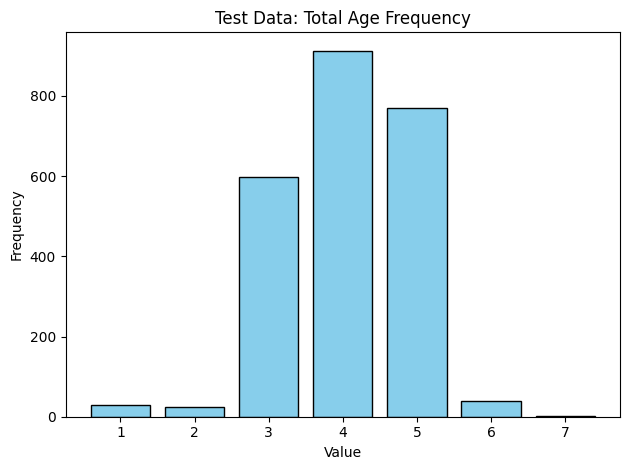

In [9]:
# show distribution by age class
from collections import Counter

count_data = Counter(test_labels)

x = list(count_data.keys())
y = list(count_data.values())

plt.bar(x, y, color='skyblue', edgecolor='black')

plt.xlabel('Value')
plt.ylabel('Frequency') 
plt.title('Test Data: Total Age Frequency')

plt.tight_layout()
#plt.savefig('ValidationAgeLabels.pdf') 
plt.show()

In [10]:
# This is a key cell block, it links the file name from the image list
# Those images are resized and then into a dict. 
# The index is maintained from the test_images_link in order to link them back to the age labels 
# This step is very efficient if the computer has sufficient memory otherwise batch processing would be necessary.


from PIL import Image
import os

def load_images(image_filenames, folder_path):

    images = {}
    target_size = (512, 512)
    
    for filename in image_filenames:
        file_path = os.path.join(folder_path, filename)
        if os.path.exists(file_path):
            with Image.open(file_path) as img:
                resized_img = img.resize(target_size, Image.LANCZOS)
                images[filename] = resized_img.copy()
        else:
            print(f"File {filename} not found in {folder_path}")
    
    return images

test_images = load_images(test_images_link, folder_testing_path)

In [11]:
list(test_images.items())[0:4]

[('Chum_SCL_2005_19_1.tif', <PIL.Image.Image image mode=RGB size=512x512>),
 ('Chum_SCL_2004_112_1.tif', <PIL.Image.Image image mode=RGB size=512x512>),
 ('Chum_SCL_2007_17_1.tif', <PIL.Image.Image image mode=RGB size=512x512>),
 ('Chum_SCL_2004_47_1.tif', <PIL.Image.Image image mode=RGB size=512x512>)]

In [12]:
# This block creates two functions to make sure all images have 3-channe, ie are color images, and if not to covert them regardless of the image imput type. 
# Important: The Keras models used in this project require all input images to be in color, have 3-channels

import cv2
from tqdm import tqdm

def process_image(img):

    if not isinstance(img, Image.Image):
        raise TypeError("Input has to be a PIL.Image.Image object.")
    
    img_np = np.array(img)
    
    print(f"Processing image with shape: {img_np.shape}")
    
    if len(img_np.shape) == 2:
        img_rgb = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)
    elif len(img_np.shape) == 3:
        if img_np.shape[2] == 1:
            img_rgb = np.repeat(img_np, 3, axis=2)
        elif img_np.shape[2] == 3:
            img_rgb = img_np
        else:
            raise ValueError(f"Unexpected number of channels in the image: {img_np.shape[2]}")
    else:
        raise ValueError(f"Unexpected image dimensions: {img_np.shape}")
    
    return img_rgb

def process_images(image_dict):
    processed_images = []
    error_count = 0
    for filename, img in tqdm(image_dict.items(), desc="Processing Images"):
        try:
            processed_img = process_image(img)
            processed_images.append(processed_img)
        except (TypeError, ValueError) as e:
            print(f"Error processing {filename}: {e}")
            error_count += 1
    
    print(f"Number of errors: {error_count}")
    return processed_images    

In [13]:
# This code running the above functions, creating the images to array and normalizing them. 
processed_test_images = process_images(test_images) 
processed_test_images = np.array(processed_test_images)
x_test = processed_test_images.astype("float32") / 255

for img in test_images.values():
     img.close()

Processing Images:  39%|███████████████████████                                    | 927/2377 [00:00<00:00, 4706.47it/s]

Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing 

Processing Images:  60%|██████████████████████████████████▋                       | 1424/2377 [00:00<00:00, 4825.38it/s]

Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)


Processing Images: 100%|██████████████████████████████████████████████████████████| 2377/2377 [00:00<00:00, 4274.81it/s]

Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 51

In [14]:
# Count of images in memory
print(x_test.shape[0], "test samples")

2377 test samples


In [15]:
# subtracting 1 from the labels. We don't have an zero total ages :-)
y_test_class = np.asarray([float(num) - 1 for num in test_labels])

In [16]:
#import tensorflow as tf
tf.keras.backend.clear_session()

In [17]:
# Checking available GPUs 
print("GPU available: ", tf.config.list_physical_devices('GPU'))

GPU available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [18]:
import tensorflow as tf
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import ConvNeXtLarge
from tensorflow.keras.models import Model
from tensorflow.keras.initializers import Constant

class LayerScale(tf.keras.layers.Layer):
    def __init__(self, init_values=1e-6, projection_dim=None, **kwargs):
        super().__init__(**kwargs)
        self.init_values = init_values
        self.projection_dim = projection_dim

    def build(self, input_shape):
        if self.projection_dim is None:
            if input_shape[-1] is None:
                raise ValueError("projection_dim must be set or inferable from input shape.")
            self.projection_dim = input_shape[-1]

        self.scale = self.add_weight(
            name='scale',
            shape=(self.projection_dim,),
            initializer=Constant(self.init_values),
            trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        return inputs * self.scale

    def get_config(self):
        config = super().get_config()
        config.update({
            'init_values': self.init_values,
            'projection_dim': self.projection_dim
        })
        return config

def build_model(input_shape=(512, 512, 3), dropout_rate=0.5, l2_reg=1e-4):
    pretrained_ConvNeXtLarge = ConvNeXtLarge(
        include_top=False,
        include_preprocessing=False,
       # weights='imagenet',
        input_shape=input_shape
    )

    # Optionally freeze part of the base
    # for layer in base_model.layers[:len(base_model.layers)//3]:
    #     layer.trainable = False

    x = GlobalAveragePooling2D()(pretrained_ConvNeXtLarge.output)
    x = Dense(4096, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.5)(x)
    predictions = Dense(1, activation='linear')(x)

    ConvNeXtLargemodel = Model(inputs=pretrained_ConvNeXtLarge.input, outputs=predictions)    

    return ConvNeXtLargemodel


In [19]:
strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    ConvNeXtLargemodel = build_model()
    ConvNeXtLargemodel.load_weights("/home/rames/ConvNeXtLarge_yolo_model_tif_phase1.hdf5")#    ConvNeXtLarge_yolo_model_file.hdf5")


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


In [20]:
ConvNeXtLarge_model_predictions = ConvNeXtLargemodel.predict(x_test) 

2025-07-28 11:26:11.921104: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8907
2025-07-28 11:26:11.950489: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8907
2025-07-28 11:26:12.184421: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x355db310 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-07-28 11:26:12.184447: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A40-48Q, Compute Capability 8.6
2025-07-28 11:26:12.184453: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA A40-48Q, Compute Capability 8.6
2025-07-28 11:26:13.835294: W tensorflow/compiler/xla/service/gpu/llvm_gpu_backend/gpu_backend_lib.cc:543] Can't find libdevice directory ${CUDA_DIR}/nvvm/libdevice. This may result in compilation or runtime failures, if the program we try to run uses routines from libdevice.
Search

75/75 [==============================] - 52s 564ms/step


In [21]:
tf.keras.backend.clear_session()

In [22]:
# Loading the efficientNet model and applying mirrorstrategy to use both GPUs. 
import tensorflow as tf
from keras.models import load_model

strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    effnetv2l_model = load_model("/home/rames/effnetv2l_yolo_model_tif_phase2.hdf5" #    effnetv2l_yolo_model_file.hdf5" #  "/opt/chumputer/effnetv2l_SAM_model_file.hdf5")
    )

#model.summary()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensor

In [23]:
# fit model 
effnetv2l_predictions = effnetv2l_model.predict(x_test) 

75/75 [==============================] - 33s 303ms/step


In [24]:
tf.keras.backend.clear_session()

In [25]:
# Loading the NASNetLarge model and applying mirrorstrategy to use both GPUs. 
import tensorflow as tf
from keras.models import load_model

strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    NASNetLarge_model = load_model("/home/rames/NASNetLarge_yolo_model_tif_phase2.hdf5" #      NASNetLarge_yolo_model_file.hdf5"  #load_model("/opt/chumputer/NASNetLarge_SAM_model_file.hdf5")
    )

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


In [26]:
NASNetLarge_predictions = NASNetLarge_model.predict(x_test) 

75/75 [==============================] - 30s 288ms/step


In [27]:
# The history of the model training. 
# This history is necessary to extract the min MSE in order to weight the models based on their individual performance against the validation data
import pickle

with open('/home/rames/effnetv2lhistory_yolo.pkl', 'rb') as f:   #effnetv2lhistory_merged
    effnet_history = pickle.load(f)

In [28]:
with open('/home/rames/NASNetLargeyolo_history.pkl', 'rb') as f:
    NASNet_history = pickle.load(f)

In [29]:
with open('/home/rames/ConvNeXtLargeyolo_history.pkl', 'rb') as f:
    ConvNeXt_history = pickle.load(f)

In [30]:
effnet_train_mse = effnet_history['mse']
effnet_test_mse = effnet_history['val_mse']
#effnet_min_mse_epoch = epochs[effnet_test_mse.index(min(effnet_test_mse))]
effnet_min_val_mse = min(effnet_test_mse)

NASNet_train_mse = NASNet_history['mse']
NASNet_test_mse = NASNet_history['val_mse']
#NASNet_min_mse_epoch = epochs[NASNet_test_mse.index(min(NASNet_test_mse))]
NASNet_min_val_mse = min(NASNet_test_mse) 

ConvNeXt_train_mse = ConvNeXt_history['mse']
ConvNeXt_test_mse = ConvNeXt_history['val_mse']
# #ConvNeXt_min_mse_epoch = epochs[ConvNeXt_test_mse.index(min(ConvNeXt_test_mse))]
ConvNeXt_min_val_mse = min(ConvNeXt_test_mse)

In [31]:
# the min MSE from each model

#print(f"Effnet v2L Minimum Validation MSE occurred at epoch {effnet_min_mse_epoch}")
print(f"Effnet v2L Minimum Validation MSE value: {effnet_min_val_mse:.4f}")

#print(f"NASNet Minimum Validation MSE occurred at epoch {NASNet_min_mse_epoch}")
print(f"NASNet Minimum Validation MSE value: {NASNet_min_val_mse:.4f}")

print(f"ConvNeXt Minimum Validation MSE value: {ConvNeXt_min_val_mse:.4f}")

Effnet v2L Minimum Validation MSE value: 0.0943
NASNet Minimum Validation MSE value: 0.1016
ConvNeXt Minimum Validation MSE value: 0.0945


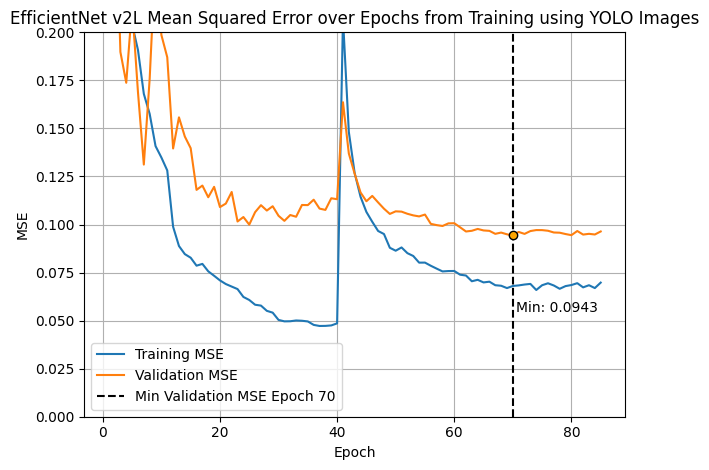

In [32]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(effnet_test_mse) + 1))

min_mse_epoch = epochs[effnet_test_mse.index(min(effnet_test_mse))]
min_val_mse = min(effnet_test_mse)

plt.plot(epochs, effnet_train_mse, label='Training MSE')
plt.plot(epochs, effnet_test_mse, label='Validation MSE')

plt.axvline(x=min_mse_epoch, color='black', linestyle='--', label=f'Min Validation MSE Epoch {min_mse_epoch}')
plt.scatter(min_mse_epoch, min_val_mse, color='orange', edgecolor='black', zorder=5)

plt.annotate(f'Min: {min_val_mse:.4f}',
             xy=(min_mse_epoch, min_val_mse),
             xytext=(min_mse_epoch + 0.5, min_val_mse - 0.04),  
             fontsize=10)

plt.title('EfficientNet v2L Mean Squared Error over Epochs from Training using YOLO Images')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.ylim(0,0.2)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

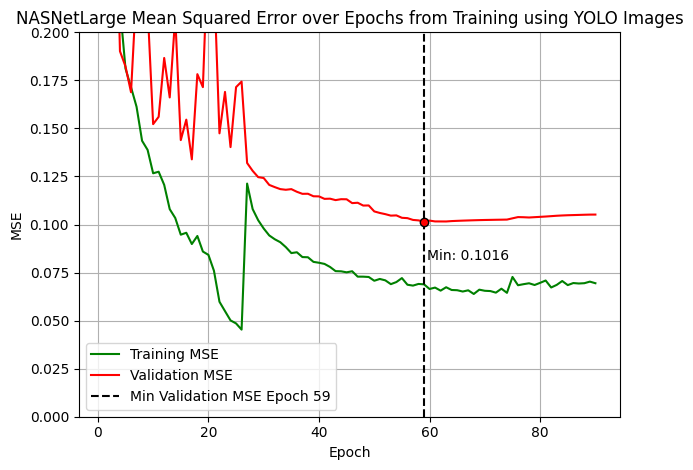

In [33]:
# import matplotlib.pyplot as plt

train_mse = NASNet_history['mse']
test_mse = NASNet_history['val_mse']

epochs = list(range(1, len(test_mse) + 1))

min_mse_epoch = epochs[test_mse.index(min(test_mse))]
min_val_mse = min(test_mse)

plt.plot(epochs, train_mse, label='Training MSE', color='green')
plt.plot(epochs, test_mse, label='Validation MSE', color='red')

plt.axvline(x=min_mse_epoch, color='black', linestyle='--', label=f'Min Validation MSE Epoch {min_mse_epoch}')
plt.scatter(min_mse_epoch, min_val_mse, color='red', edgecolor='black', zorder=5)

plt.annotate(f'Min: {min_val_mse:.4f}',
             xy=(min_mse_epoch, min_val_mse),
             xytext=(min_mse_epoch + 0.5, min_val_mse - 0.02),  
             fontsize=10)

plt.title('NASNetLarge Mean Squared Error over Epochs from Training using YOLO Images')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.ylim(0,0.2)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

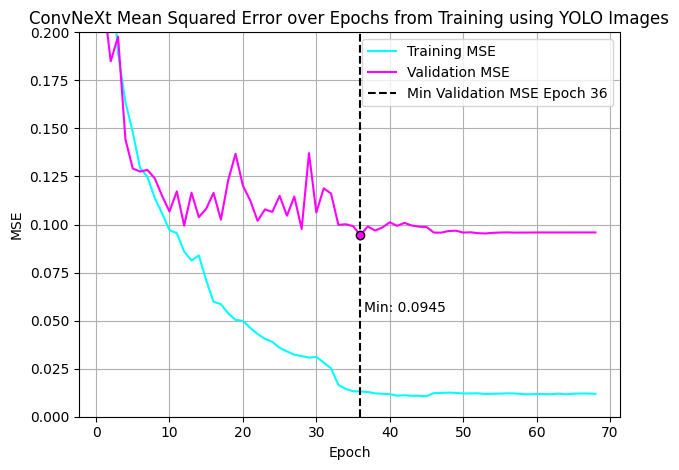

In [34]:
import matplotlib.pyplot as plt

train_mse = ConvNeXt_history['mse']
test_mse = ConvNeXt_history['val_mse']

epochs = list(range(1, len(test_mse) + 1))

min_mse_epoch = epochs[test_mse.index(min(test_mse))]
min_val_mse = min(test_mse)

plt.plot(epochs, train_mse, label='Training MSE', color='cyan')
plt.plot(epochs, test_mse, label='Validation MSE', color='magenta')

plt.axvline(x=min_mse_epoch, color='black', linestyle='--', label=f'Min Validation MSE Epoch {min_mse_epoch}')
plt.scatter(min_mse_epoch, min_val_mse, color='magenta', edgecolor='black', zorder=5)

plt.annotate(f'Min: {min_val_mse:.4f}',
             xy=(min_mse_epoch, min_val_mse),
             xytext=(min_mse_epoch + 0.5, min_val_mse - 0.04),  
             fontsize=10)

plt.title('ConvNeXt Mean Squared Error over Epochs from Training using YOLO Images')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.ylim(0,0.2)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
# Creating weights for each model inversely proportional to their validation MSE
# weighting each of the predictions to create final prediction

import numpy as np
from sklearn.metrics import mean_squared_error

mse1 = effnet_min_val_mse
mse2 = NASNet_min_val_mse
mse3 = ConvNeXt_min_val_mse

weights = np.array([1/mse1, 1/mse2, 1/mse3])
weights /= weights.sum()  

test_predictions1 = effnetv2l_predictions + 1
test_predictions2 = NASNetLarge_predictions + 1
test_predictions3 = ConvNeXtLarge_model_predictions + 1

predictions_round1 = np.round(test_predictions1)
predictions_round2 = np.round(test_predictions2)
predictions_round3 = np.round(test_predictions3)

combined_test_predictions = (
    weights[0] * test_predictions1 +
    weights[1] * test_predictions2 +
    weights[2] * test_predictions3
)

combined_test_predictions_round = np.round(combined_test_predictions)

In [36]:
# combining data to create a dataframe that includes file name, labels, as well as the predictions. 
test_labels = np.array(test_labels)
combined_test_predictions = np.array(combined_test_predictions)
combined_test_predictions_round = np.array(combined_test_predictions_round)
test_predictions1 = np.array(test_predictions1)
test_predictions2 = np.array(test_predictions2)
test_predictions3 = np.array(test_predictions3)

In [37]:
# output dataframe
pred = np.concatenate((test_labels.reshape(-1, 1), combined_test_predictions.reshape(-1, 1), test_predictions1.reshape(-1, 1), 
                       test_predictions2.reshape(-1, 1), test_predictions3.reshape(-1, 1), combined_test_predictions_round.reshape(-1, 1)), axis=1)  


In [38]:
# dataframe headers
pred_df = pd.DataFrame(data=pred, columns=['y_test', 'combined_predictions', 'effnetv2l', 'NASNetLarge', 'ConvNeXt', 'combined_test_predictions_round']) 

In [39]:
pred_df.head(3)

,y_test,combined_predictions,effnetv2l,NASNetLarge,ConvNeXt,combined_test_predictions_round
0,1.0,1.409803,1.254286,1.200932,1.759894,1.0
1,1.0,0.996836,1.019965,0.970773,0.997909,1.0
2,1.0,0.964411,0.905505,1.014073,0.977227,1.0


In [40]:
# combined prediction's R^2 value
from sklearn.metrics import r2_score

r2 = r2_score(pred_df['y_test'], pred_df['combined_predictions'])

In [41]:
round(r2,3)

0.884

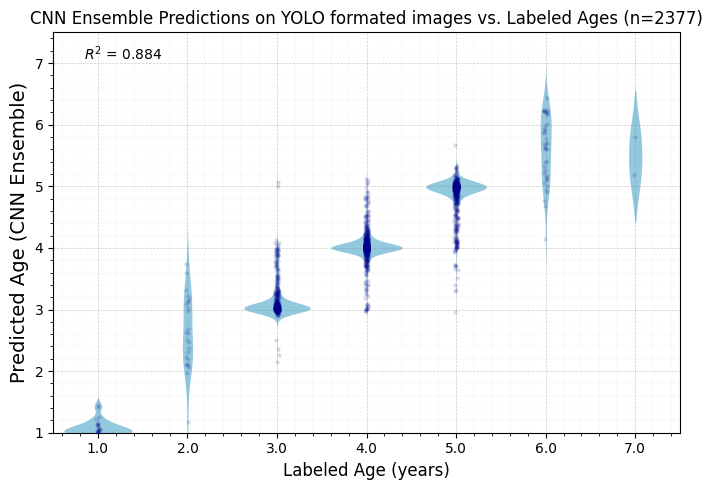

In [45]:
# Final prediction plot vs labeled ages

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

pred_df['y_test'] = pd.to_numeric(pred_df['y_test'], errors='coerce')

r2 = r2_score(pred_df['y_test'], pred_df['combined_predictions'])

plt.figure(figsize=(7, 5))

sns.violinplot(data=pred_df, x='y_test', y='combined_predictions', inner=None, linewidth=0, color='skyblue')

size = 3  
sns.stripplot(data=pred_df, x='y_test', y='combined_predictions', color='darkblue', alpha=0.15, size=size, jitter=0.02)

#sns.regplot(data=pred_df, x='y_test', y='combined_predictions', scatter=False, color='red', line_kws={"linewidth": 2})

plt.ylabel("Predicted Age (CNN Ensemble)", fontsize=14)
plt.xlabel("Labeled Age (years)", fontsize=12)
plt.title('CNN Ensemble Predictions on YOLO formated images vs. Labeled Ages (n=2377)', fontsize=12)
plt.ylim(1, 7.5)

plt.text(x=0.05, y=0.93, s=f"$R^2$ = {r2:.3f}", fontsize=10, transform=plt.gca().transAxes)


plt.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray', alpha=0.4)
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', linewidth=0.3, color='gray', alpha=0.3)
plt.tight_layout()
plt.savefig('ViolinPlotYOLO.png', dpi=700)
plt.show()


In [46]:
from sklearn.metrics import confusion_matrix

y_true = pred_df['y_test']
y_pred = pred_df['combined_test_predictions_round']

labels = [1, 2, 3, 4, 5, 6, 7]

conf_matrix = confusion_matrix(y_true, y_pred, labels=labels)

conf_df = pd.DataFrame(conf_matrix, index=labels, columns=labels)

print("Confusion Matrix:")
print(conf_df)

Confusion Matrix:
    1   2    3    4    5   6  7
1  29   0    0    0    0   0  0
2   1  10   12    2    0   0  0
3   0   3  541   52    2   0  0
4   0   0   28  853   32   0  0
5   0   0    4   74  691   1  0
6   0   0    0    1   15  24  0
7   0   0    0    0    1   1  0


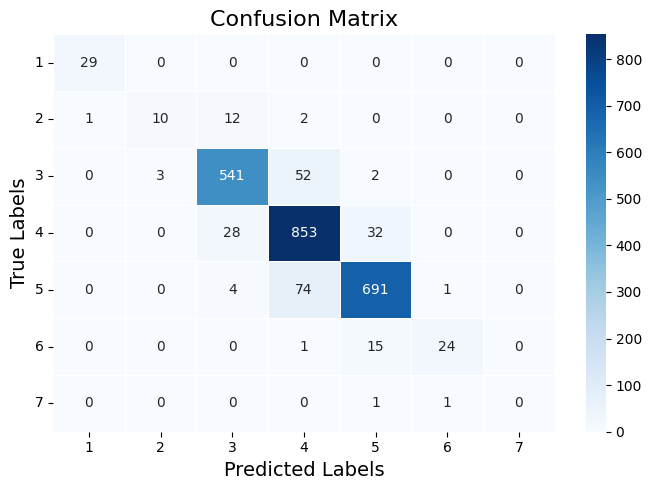

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_true = pred_df['y_test']
y_pred = pred_df['combined_test_predictions_round']

labels = [1, 2, 3, 4, 5, 6, 7]

conf_matrix = confusion_matrix(y_true, y_pred, labels=labels)

conf_df = pd.DataFrame(conf_matrix, index=labels, columns=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(conf_df, annot=True, fmt='d',  cmap='Blues', cbar=True, linewidths=0.5, xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('ConfusionMatrixyolo2.png', dpi=700)
plt.show()


In [49]:
overall_accuracy = np.trace(conf_matrix) / np.sum(conf_matrix)

print("Overall Accuracy: {:.2f}%".format(overall_accuracy * 100))

Overall Accuracy: 90.37%


In [50]:
num_classes = 7

class_accuracy = np.diag(conf_matrix) / conf_matrix.sum(axis=1)
class_counts = conf_matrix.sum(axis=1)

for class_idx, (acc, count) in enumerate(zip(class_accuracy, class_counts), start=1):
    print("Age Class {} - Images: {}, Accuracy: {:.2f}%".format(class_idx, count, acc * 100)) # +1

Age Class 1 - Images: 29, Accuracy: 100.00%
Age Class 2 - Images: 25, Accuracy: 40.00%
Age Class 3 - Images: 598, Accuracy: 90.47%
Age Class 4 - Images: 913, Accuracy: 93.43%
Age Class 5 - Images: 770, Accuracy: 89.74%
Age Class 6 - Images: 40, Accuracy: 60.00%
Age Class 7 - Images: 2, Accuracy: 0.00%


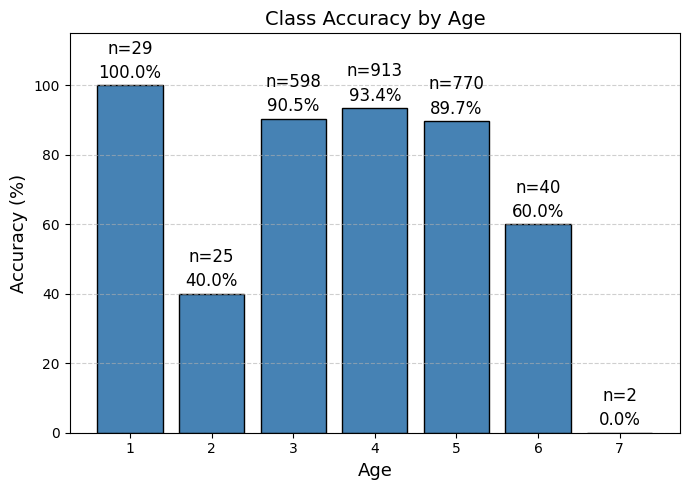

In [51]:
import numpy as np
import matplotlib.pyplot as plt


num_classes = 7
class_accuracy = np.diag(conf_matrix) / conf_matrix.sum(axis=1)
class_counts = conf_matrix.sum(axis=1)


age_classes = list(range(1, num_classes + 1))


plt.figure(figsize=(7, 5))
bars = plt.bar(age_classes, class_accuracy * 100, color='steelblue', edgecolor='black')


for bar, acc, count in zip(bars, class_accuracy, class_counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f"{acc*100:.1f}%", 
             ha='center', va='bottom', fontsize=12)
    # plt.text(bar.get_x() + bar.get_width() / 2, 3, f"n={count}", 
    #          ha='center', va='bottom', fontsize=10, color='black')
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 8,  
        f"n={count}", 
        ha='center', va='bottom',
        fontsize=12, color='black'
    )

plt.ylim(0, 115)
plt.xticks(age_classes)
plt.xlabel("Age", fontsize=13)
plt.ylabel("Accuracy (%)", fontsize=13)
plt.title("Class Accuracy by Age", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('accuracybarplotyolo2.png', dpi=700)
plt.show()


In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(test_labels, combined_test_predictions_round)
mae = mean_absolute_error(test_labels, combined_test_predictions_round)
r2 = r2_score(test_labels, combined_test_predictions_round)

print('MSE: {}'.format(mse))
print('MAE: {}'.format(mae))
print('R^2: {}'.format(r2))

MSE: 0.10896087437868118
MAE: 0.10054691135883331
R^2: 0.8637444972991943


In [53]:
end = time.time()
end - start

939.9143462181091

In [54]:
df_test.reset_index(drop=True, inplace=True)
pred_df.reset_index(drop=True, inplace=True)

In [55]:
test_with_outputs = pd.concat([df_test, pred_df], axis=1)

In [56]:
comparison = test_with_outputs['label'] == test_with_outputs['y_test']
print(comparison)

0       True
1       True
2       True
3       True
4       True
        ... 
2372    True
2373    True
2374    True
2375    True
2376    True
Length: 2377, dtype: bool


In [57]:
mismatches = test_with_outputs[~comparison]
print("Mismatches:")
print(mismatches)

Mismatches:
Empty DataFrame
Columns: [filename, label, y_test, combined_predictions, effnetv2l, NASNetLarge, ConvNeXt, combined_test_predictions_round]
Index: []


In [58]:
test_with_outputs['combined_test_predictions_round'] = test_with_outputs['combined_test_predictions_round'].astype(int)

In [59]:
test_with_outputs.tail()

,filename,label,y_test,combined_predictions,effnetv2l,NASNetLarge,ConvNeXt,combined_test_predictions_round
2372,ChumBY17_22000_5306_158_585_6.tif,6,6.0,5.611824,5.825315,5.200967,5.780129,6
2373,2017_fish cr_cd 33_sc 5_6.tif,6,6.0,5.878202,5.730438,6.038668,5.876966,6
2374,2017_sawmill cr_cd 193_sc 10_KA_6.tif,6,6.0,5.923492,5.830302,6.103772,5.849154,6
2375,Chum_SCL_1992_04_7.tif,7,7.0,5.177288,5.208711,5.352584,4.982745,5
2376,ChumBY21_24947_3671_194_499_7.tif,7,7.0,5.793825,5.986843,5.688808,5.698148,6


In [60]:
comparison_w_pred = test_with_outputs['combined_test_predictions_round'] == test_with_outputs['y_test']

In [61]:
comparison_w_pred

0        True
1        True
2        True
3        True
4        True
        ...  
2372     True
2373     True
2374     True
2375    False
2376    False
Length: 2377, dtype: bool

In [62]:
mismatch_data = test_with_outputs[~comparison_w_pred]
mismatch_data.head(10)

,filename,label,y_test,combined_predictions,effnetv2l,NASNetLarge,ConvNeXt,combined_test_predictions_round
29,ChumBY19_23622_5310_22_214_2.tif,2,2.0,2.978001,2.951762,2.932639,3.046484,3
30,ChumBY19_23636_3794_446_446109_2.tif,2,2.0,3.017078,3.113196,2.983231,2.952271,3
34,ChumBY13_18060_5306_292_916_2.tif,2,2.0,3.116992,3.781269,2.856582,2.693751,3
35,ChumBY20_24292_5310_80_587_2.tif,2,2.0,2.615537,2.134760,3.184187,2.568218,3
36,ChumBY20_24422_5323_52_399_2.tif,2,2.0,3.146146,3.225438,3.141425,3.071103,3
37,ChumBY19_23647_3681_407_40707_2.tif,2,2.0,3.084968,2.962128,3.242894,3.061126,3
38,ChumBY20_24292_5310_1_53_2.tif,2,2.0,3.211802,3.133792,3.115893,3.379166,3
39,ChumBY14_19636_5310_7_62_2.tif,2,2.0,3.588031,3.796233,3.174749,3.763891,4
40,ChumBY20_24353_5306_243_410_2.tif,2,2.0,3.165538,3.319418,3.160298,3.016255,3
41,ChumBY19_23610_5306_115_499_2.tif,2,2.0,3.738974,3.608955,3.676980,3.926894,4


In [63]:
mismatch_data.count()

filename                           229
label                              229
y_test                             229
combined_predictions               229
effnetv2l                          229
NASNetLarge                        229
ConvNeXt                           229
combined_test_predictions_round    229
dtype: int64

In [64]:
mismatch_data.to_csv('EnsemblingWrongPredwithImageID_512_Finalyolo2.csv')

In [65]:
test_with_outputs.to_csv('EnsemblingPredwithImageID_512_Finalyolo2.csv')

In [ ]:
with open('/home/rames/NASNetLargeyolo_history.pkl', 'rb') as f:
    NASNet_history = pickle.load(f)

# Step 2: Convert to DataFrame
#history_df = pd.DataFrame(NASNet_history.history)

# Step 3: Save to CSV
#history_df.to_csv('/home/rames/NASNetLargeyolo_history.csv', index=False)

In [ ]:
print(type(NASNet_history))
print(NASNet_history.keys())


In [ ]:
#import pandas as pd

# Convert dictionary to DataFrame
history_df = pd.DataFrame(NASNet_history)

# Save DataFrame to CSV
history_df.to_csv('/home/rames/NASNetLargeyolo_history.csv', index=False)

print("CSV file saved at /home/rames/NASNetLargeyolo_history.csv")


In [ ]:
end = time.time()
end - start

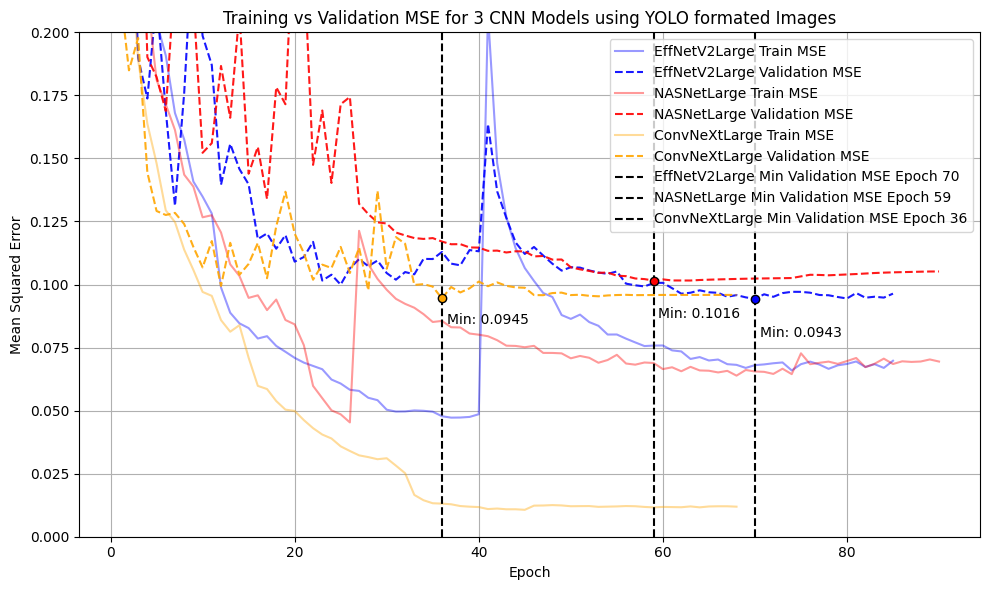

In [5]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

# Load all three histories
with open('/home/rames/effnetv2lhistory_merged.pkl', 'rb') as f:
    effnet_history = pickle.load(f)

effnet_history_df = pd.DataFrame(effnet_history)
effnet_history_df.to_csv('effnetv2Largeyolo_history.csv', index=False)

with open('/home/rames/NASNetLargeyolo_history.pkl', 'rb') as f:
    NASNet_history = pickle.load(f)

NASNet_history_df = pd.DataFrame(NASNet_history)
NASNet_history_df.to_csv('NASNetLargeyolo_history.csv', index=False)      

with open('/home/rames/ConvNeXtLargeyolo_history.pkl', 'rb') as f:
    ConvNeXt_history = pickle.load(f)

ConvNeXt_history_df = pd.DataFrame(ConvNeXt_history)
ConvNeXt_history_df.to_csv('ConvNeXtLargeyolo_history.csv', index=False)        

# Extract metrics
effnet_train_mse = effnet_history['mse']
effnet_val_mse = effnet_history['val_mse']
effnet_epochs = list(range(1, len(effnet_train_mse) + 1))

NASNet_train_mse = NASNet_history['mse']
NASNet_val_mse = NASNet_history['val_mse']
nasnet_epochs = list(range(1, len(NASNet_train_mse) + 1))

ConvNeXt_train_mse = ConvNeXt_history['mse']
ConvNeXt_val_mse = ConvNeXt_history['val_mse']
convnext_epochs = list(range(1, len(ConvNeXt_train_mse) + 1))

# Plot
plt.figure(figsize=(10, 6))

plt.plot(effnet_epochs, effnet_train_mse, label='EffNetV2Large Train MSE', linestyle='-', color='blue', alpha=0.4)
plt.plot(effnet_epochs, effnet_val_mse, label='EffNetV2Large Validation MSE', linestyle='--', color='blue', alpha=0.9)

plt.plot(nasnet_epochs, NASNet_train_mse, label='NASNetLarge Train MSE', linestyle='-', color='red', alpha=0.4)
plt.plot(nasnet_epochs, NASNet_val_mse, label='NASNetLarge Validation MSE', linestyle='--', color='red', alpha=0.9)

plt.plot(convnext_epochs, ConvNeXt_train_mse, label='ConvNeXtLarge Train MSE', linestyle='-', color='orange', alpha=0.4)
plt.plot(convnext_epochs, ConvNeXt_val_mse, label='ConvNeXtLarge Validation MSE', linestyle='--', color='orange', alpha=0.9)


EffNetV2L_min_mse_epoch = effnet_epochs[effnet_val_mse.index(min(effnet_val_mse))]
EffNetV2L_min_val_mse = min(effnet_val_mse)

plt.axvline(x=EffNetV2L_min_mse_epoch, color='black', linestyle='--', label=f'EffNetV2Large Min Validation MSE Epoch {EffNetV2L_min_mse_epoch}')
plt.scatter(EffNetV2L_min_mse_epoch, EffNetV2L_min_val_mse, color='blue', edgecolor='black', zorder=5)

plt.annotate(f'Min: {EffNetV2L_min_val_mse:.4f}',
             xy=(EffNetV2L_min_mse_epoch, EffNetV2L_min_val_mse),
             xytext=(EffNetV2L_min_mse_epoch + 0.5, EffNetV2L_min_val_mse - 0.015),  
             fontsize=10)

NASNet_min_mse_epoch = nasnet_epochs[NASNet_val_mse.index(min(NASNet_val_mse))]
NASNet_min_val_mse = min(NASNet_val_mse)

plt.axvline(x=NASNet_min_mse_epoch, color='black', linestyle='--', label=f'NASNetLarge Min Validation MSE Epoch {NASNet_min_mse_epoch}')
plt.scatter(NASNet_min_mse_epoch, NASNet_min_val_mse, color='red', edgecolor='black', zorder=5)

plt.annotate(f'Min: {NASNet_min_val_mse:.4f}',
             xy=(NASNet_min_mse_epoch, NASNet_min_val_mse),
             xytext=(NASNet_min_mse_epoch + 0.5, NASNet_min_val_mse - 0.015),  
             fontsize=10)

ConvNeXt_min_mse_epoch = convnext_epochs[ConvNeXt_val_mse.index(min(ConvNeXt_val_mse))]
ConvNeXt_min_val_mse = min(ConvNeXt_val_mse)

plt.axvline(x=ConvNeXt_min_mse_epoch, color='black', linestyle='--', label=f'ConvNeXtLarge Min Validation MSE Epoch {ConvNeXt_min_mse_epoch}')
plt.scatter(ConvNeXt_min_mse_epoch, ConvNeXt_min_val_mse, color='orange', edgecolor='black', zorder=5)

plt.annotate(f'Min: {ConvNeXt_min_val_mse:.4f}',
             xy=(ConvNeXt_min_mse_epoch, ConvNeXt_min_val_mse),
             xytext=(ConvNeXt_min_mse_epoch + 0.5, ConvNeXt_min_val_mse - 0.01),  
             fontsize=10)


plt.title('Training vs Validation MSE for 3 CNN Models using YOLO formated Images')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.ylim(0, 0.2)
plt.grid(True)
plt.legend()
plt.tight_layout()
#plt.savefig('yolo3modeltrainingplot.png', dpi=700)
plt.show()
